In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [3]:
df.drop(['id'], axis=1, inplace=True)

In [4]:
df.isna().sum()

age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,20.545821,4.002337,71.987261,7.072758,62.506672
std,2.260238,2.359880,17.430098,1.744811,18.916884
min,17.000000,0.080000,40.600000,4.100000,19.599000
25%,19.000000,1.970000,57.000000,5.600000,48.800000
50%,21.000000,4.000000,72.600000,7.100000,62.600000
75%,23.000000,6.050000,87.200000,8.600000,76.300000
max,24.000000,7.910000,99.400000,9.900000,100.000000


In [7]:
categorial_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns 

In [8]:
(categorial_cols, numerical_cols)

(Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
        'facility_rating', 'exam_difficulty'],
       dtype='object'),
 Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score'], dtype='object'))

<Axes: xlabel='internet_access', ylabel='count'>

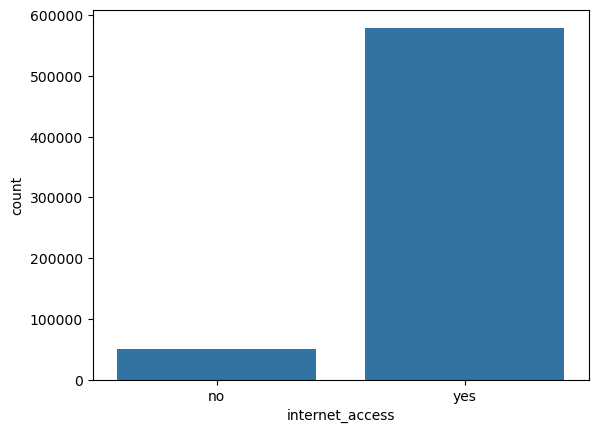

In [9]:
sns.countplot(x=df['internet_access'])

<Axes: xlabel='study_hours', ylabel='exam_score'>

c:\Users\sayan\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\sayan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


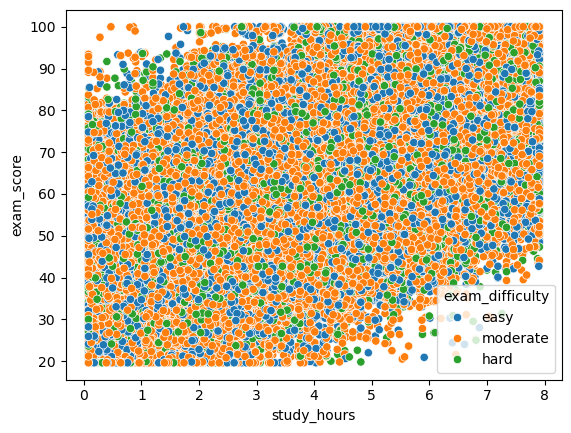

In [10]:
sns.scatterplot(x=df['study_hours'], y=df['exam_score'], hue=df['exam_difficulty'])

<Axes: >

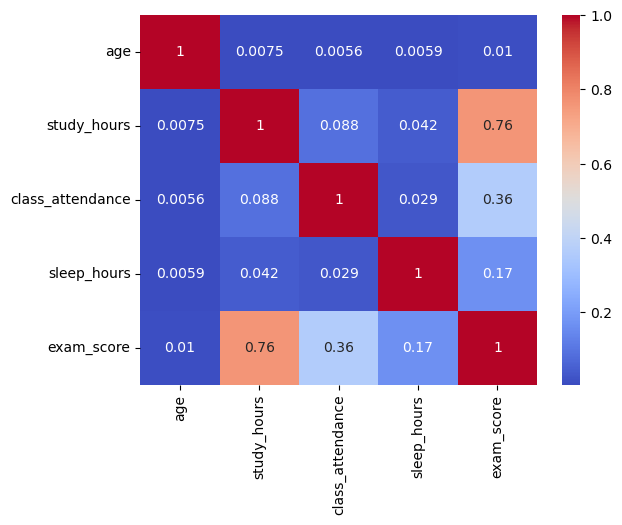

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [12]:
label_encode_cols = [
    'internet_access',    
    'sleep_quality',    
    'facility_rating',  
    'exam_difficulty'   
    ]
one_hot_cols = [
    'gender',
    'course',
    'study_method'
]



In [13]:
df['internet_access'] = pd.Categorical(
    df['internet_access'],
    categories=['no', 'yes'],
    ordered=True
).codes
df['sleep_quality'] = pd.Categorical(
    df['sleep_quality'],
    categories=['poor', 'average', 'good'],
    ordered=True
).codes

# facility_rating: low < medium < high
df['facility_rating'] = pd.Categorical(
    df['facility_rating'],
    categories=['low', 'medium', 'high'],
    ordered=True
).codes

# exam_difficulty: easy < moderate < hard
df['exam_difficulty'] = pd.Categorical(
    df['exam_difficulty'],
    categories=['easy', 'moderate', 'hard'],
    ordered=True
).codes

In [14]:
df = pd.get_dummies(
    df,
    columns=one_hot_cols,
    drop_first=True,    # removes dummy trap
    dtype=int
)


In [15]:
x_train = df.drop('exam_score', axis=1)
y_train = df['exam_score']

In [16]:
# from sklearn.model_selection import train_test_split
# x_train, x_test, y_train, y_test = train_test_split(
#     x, y, test_size=0.2, random_state=42
# )

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
#x_test_scaled  = scaler.transform(x_test)


In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [19]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}


In [20]:
results = []

for name, model in models.items():
    
    # Use scaled data only where needed
    if name in ['LinearRegression', 'Ridge', 'Lasso']:
        model.fit(x_train_scaled, y_train)
        # y_pred = model.predict(x_test_scaled)
    else:
        model.fit(x_train, y_train)
        # y_pred = model.predict(x_test)

    # mae = mean_absolute_error(y_test, y_pred)
    # rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    # r2 = r2_score(y_test, y_pred)

    # results.append([name, mae, rmse, r2])


In [21]:

# results_df = pd.DataFrame(
#     results,
#     columns=['Model', 'MAE', 'RMSE', 'R2']
# ).sort_values(by='R2', ascending=False)

# print(results_df)


In [ ]:
# best_model_name = results_df.iloc[0]['Model']
# best_model = models[best_model_name]

# if best_model_name in ['LinearRegression', 'Ridge', 'Lasso', 'SVR']:
#     best_model.fit(X_train_scaled, y_train)
# else:
#     best_model.fit(x_train, y_train)


NameError: name 'results_df' is not defined

In [24]:
from sklearn.linear_model import Ridge

final_model = Ridge(alpha=1.0)

final_model.fit(x_train_scaled, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [34]:
df_test = pd.read_csv('test.csv')
id = df_test['id']
df_test.drop(['id'], axis=1, inplace=True)

In [26]:


df_test['internet_access'] = pd.Categorical(
    df_test['internet_access'],
    categories=['no', 'yes'],
    ordered=True
).codes
df_test['sleep_quality'] = pd.Categorical(
    df_test['sleep_quality'],
    categories=['poor', 'average', 'good'],
    ordered=True
).codes

# facility_rating: low < medium < high
df_test['facility_rating'] = pd.Categorical(
    df_test['facility_rating'],
    categories=['low', 'medium', 'high'],
    ordered=True
).codes

# exam_difficulty: easy < moderate < hard
df_test['exam_difficulty'] = pd.Categorical(
    df_test['exam_difficulty'],
    categories=['easy', 'moderate', 'hard'],
    ordered=True
).codes

In [27]:
df_test = pd.get_dummies(
    df_test,
    columns=one_hot_cols,
    drop_first=True,    # removes dummy trap
    dtype=int
)


In [30]:
x_test = df_test

In [31]:
x_test_scaled  = scaler.transform(x_test)

In [33]:
y_test_pred = final_model.predict(x_test_scaled)


In [37]:
submission = pd.DataFrame({
    'id': id,        # replace 'id' with actual column name
    'exam_score': y_test_pred
})


In [38]:
submission.to_csv('submission.csv', index=False)
